# Домашнее задание №3
## Поиск аномалий в банковских транзакциях

### Цель работы

Построить и сравнить несколько алгоритмов обнаружения аномалий на данных банковских транзакций.

Датасет содержит реальные банковские транзакции, признаки которых были анонимизированы.
Признаки `V1–V28` представляют собой главные компоненты, полученные после PCA-преобразования исходных данных.

Целевая переменная `Class` принимает два значения:

- `0` — обычная транзакция;
- `1` — мошенническая транзакция.

Особенность задачи заключается в сильном дисбалансе классов: мошеннические операции составляют менее 1% наблюдений.

В работе будут рассмотрены методы обнаружения аномалий, основанные на:

- расстояниях;
- локальной плотности;
- изоляции наблюдений.

Качество моделей будет проверено с использованием истинных значений `Class`, а структура данных дополнительно исследована с помощью t-SNE.

In [54]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.covariance import LedoitWolf
from sklearn.neighbors import LocalOutlierFactor
from sklearn.ensemble import IsolationForest
from sklearn.manifold import TSNE

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_auc_score,
    average_precision_score
)

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 200)

RANDOM_STATE = 42

print("Библиотеки успешно загружены")

Библиотеки успешно загружены


## 1. Загрузка и первичное исследование данных

На первом этапе загрузим датасет и проверим:

- размер данных;
- названия признаков;
- типы переменных;
- наличие пропущенных значений;
- наличие дубликатов.

Также отдельно исследуем распределение целевой переменной `Class` и определим долю аномальных транзакций. Полученное значение будет использоваться далее как экспертная оценка загрязнённости данных (`contamination`).

In [55]:
from pathlib import Path

DATA_PATH = Path("creditcard.zip")

df = pd.read_csv(DATA_PATH)

print("=" * 70)
print("ДАТАСЕТ УСПЕШНО ЗАГРУЖЕН")
print("=" * 70)

print(f"Количество строк: {df.shape[0]}")
print(f"Количество столбцов: {df.shape[1]}")

print("\nПервые 5 строк:")
display(df.head())

ДАТАСЕТ УСПЕШНО ЗАГРУЖЕН
Количество строк: 284807
Количество столбцов: 31

Первые 5 строк:


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,V11,V12,V13,V14,V15,V16,V17,V18,V19,V20,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,0.090794,-0.551600,-0.617801,-0.991390,-0.311169,1.468177,-0.470401,0.207971,0.025791,0.403993,0.251412,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,-0.166974,1.612727,1.065235,0.489095,-0.143772,0.635558,0.463917,-0.114805,-0.183361,-0.145783,-0.069083,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,0.207643,0.624501,0.066084,0.717293,-0.165946,2.345865,-2.890083,1.109969,-0.121359,-2.261857,0.524980,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,-0.054952,-0.226487,0.178228,0.507757,-0.287924,-0.631418,-1.059647,-0.684093,1.965775,-1.232622,-0.208038,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,0.753074,-0.822843,0.538196,1.345852,-1.119670,0.175121,-0.451449,-0.237033,-0.038195,0.803487,0.408542,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


## 2. Первичный анализ данных

Проведём базовый анализ датасета:

- проверим размерность;
- посмотрим типы признаков;
- проверим наличие пропусков;
- проверим наличие дубликатов;
- изучим описательные статистики.

Это позволит понять структуру данных перед построением алгоритмов поиска аномалий.

In [56]:
print("=" * 70)
print("ОБЩАЯ ИНФОРМАЦИЯ О ДАТАСЕТЕ")
print("=" * 70)

print(f"Количество строк: {df.shape[0]}")
print(f"Количество столбцов: {df.shape[1]}")

print("\n" + "=" * 70)
print("ТИПЫ ДАННЫХ")
print("=" * 70)
print(df.dtypes)

print("\n" + "=" * 70)
print("ПРОПУЩЕННЫЕ ЗНАЧЕНИЯ")
print("=" * 70)

missing_values = df.isna().sum()

print(missing_values)

print("\nОбщее количество пропусков:")
print(missing_values.sum())

print("\n" + "=" * 70)
print("ДУБЛИКАТЫ")
print("=" * 70)

duplicates_count = df.duplicated().sum()

print(f"Количество полных дубликатов: {duplicates_count}")

ОБЩАЯ ИНФОРМАЦИЯ О ДАТАСЕТЕ
Количество строк: 284807
Количество столбцов: 31

ТИПЫ ДАННЫХ
Time      float64
V1        float64
V2        float64
V3        float64
V4        float64
V5        float64
V6        float64
V7        float64
V8        float64
V9        float64
V10       float64
V11       float64
V12       float64
V13       float64
V14       float64
V15       float64
V16       float64
V17       float64
V18       float64
V19       float64
V20       float64
V21       float64
V22       float64
V23       float64
V24       float64
V25       float64
V26       float64
V27       float64
V28       float64
Amount    float64
Class       int64
dtype: object

ПРОПУЩЕННЫЕ ЗНАЧЕНИЯ
Time      0
V1        0
V2        0
V3        0
V4        0
V5        0
V6        0
V7        0
V8        0
V9        0
V10       0
V11       0
V12       0
V13       0
V14       0
V15       0
V16       0
V17       0
V18       0
V19       0
V20       0
V21       0
V22       0
V23       0
V24       0
V25       0
V26 

### 2.1 Обработка дубликатов

В датасете обнаружено 1081 полное дублирующееся наблюдение.

В рамках данной работы дубликаты оставлены в исходном наборе данных, поскольку задача предполагает использование исходной доли объектов класса `Fraud` в качестве экспертной оценки параметра `contamination`.

Удаление наблюдений могло бы изменить исходное распределение классов и рассчитанную оценку загрязнённости. При этом наличие дубликатов учитывается при интерпретации результатов.

### 2.2 Описательные статистики

Рассмотрим основные статистические характеристики признаков:

- среднее значение;
- стандартное отклонение;
- минимальное и максимальное значения;
- квартили.

Признаки `V1–V28` являются результатом PCA-преобразования, поэтому их исходный смысл неизвестен.
Дополнительно в данных присутствуют признаки `Time` и `Amount`.

In [57]:
statistics = df.describe().T

print("=" * 70)
print("ОПИСАТЕЛЬНЫЕ СТАТИСТИКИ")
print("=" * 70)

display(statistics)

ОПИСАТЕЛЬНЫЕ СТАТИСТИКИ


,count,mean,std,min,25%,50%,75%,max
Time,284807.0,9.481386e+04,47488.145955,0.000000,54201.500000,84692.000000,139320.500000,172792.000000
V1,284807.0,1.175161e-15,1.958696,-56.407510,-0.920373,0.018109,1.315642,2.454930
V2,284807.0,3.384974e-16,1.651309,-72.715728,-0.598550,0.065486,0.803724,22.057729
V3,284807.0,-1.379537e-15,1.516255,-48.325589,-0.890365,0.179846,1.027196,9.382558
V4,284807.0,2.094852e-15,1.415869,-5.683171,-0.848640,-0.019847,0.743341,16.875344
V5,284807.0,1.021879e-15,1.380247,-113.743307,-0.691597,-0.054336,0.611926,34.801666
V6,284807.0,1.494498e-15,1.332271,-26.160506,-0.768296,-0.274187,0.398565,73.301626
V7,284807.0,-5.620335e-16,1.237094,-43.557242,-0.554076,0.040103,0.570436,120.589494
V8,284807.0,1.149614e-16,1.194353,-73.216718,-0.208630,0.022358,0.327346,20.007208
V9,284807.0,-2.414189e-15,1.098632,-13.434066,-0.643098,-0.051429,0.597139,15.594995


## 3. Анализ целевой переменной Class

Переменная `Class` показывает, является ли транзакция мошеннической:

- `0` — обычная транзакция;
- `1` — мошенническая транзакция.

Так как задача поиска аномалий предполагает, что аномальных объектов значительно меньше, чем нормальных, вычислим реальную долю мошеннических транзакций.

Эту долю будем использовать как экспертную оценку параметра `contamination` при настройке алгоритмов обнаружения аномалий.

In [58]:
class_counts = df["Class"].value_counts().sort_index()

class_percent = (
    df["Class"]
    .value_counts(normalize=True)
    .sort_index()
    * 100
)

class_table = pd.DataFrame({
    "Количество": class_counts,
    "Процент": class_percent
})

class_table.index = [
    "Нормальные транзакции (0)",
    "Мошеннические транзакции (1)"
]

display(class_table)

normal_count = (df["Class"] == 0).sum()
fraud_count = (df["Class"] == 1).sum()

contamination = df["Class"].mean()

print("=" * 70)
print("ЭКСПЕРТНАЯ ОЦЕНКА ЗАГРЯЗНЁННОСТИ")
print("=" * 70)

print(f"Нормальных транзакций: {normal_count}")
print(f"Мошеннических транзакций: {fraud_count}")

print(f"\nДоля аномалий: {contamination:.8f}")
print(f"Процент аномалий: {contamination * 100:.6f}%")

,Количество,Процент
Нормальные транзакции (0),284315,99.827251
Мошеннические транзакции (1),492,0.172749


ЭКСПЕРТНАЯ ОЦЕНКА ЗАГРЯЗНЁННОСТИ
Нормальных транзакций: 284315
Мошеннических транзакций: 492

Доля аномалий: 0.00172749
Процент аномалий: 0.172749%


### 3.1 Распределение классов

Визуализируем распределение нормальных и мошеннических транзакций.

Ожидается сильный дисбаланс классов, поскольку мошеннические операции составляют лишь небольшую часть всех транзакций.

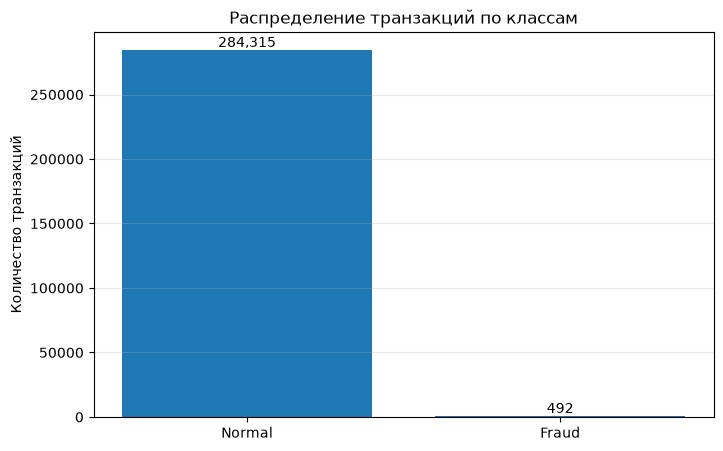

In [59]:
plt.figure(figsize=(8, 5))

labels = ["Normal", "Fraud"]
values = [normal_count, fraud_count]

bars = plt.bar(labels, values)

plt.title("Распределение транзакций по классам")
plt.ylabel("Количество транзакций")

plt.grid(
    axis="y",
    alpha=0.3
)

for bar, value in zip(bars, values):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f"{value:,}",
        ha="center",
        va="bottom"
    )

plt.show()

## 4. Исследовательский анализ признаков

Теперь рассмотрим распределения основных признаков.

Поскольку признаки `V1–V28` являются результатом PCA-преобразования, их исходный физический смысл неизвестен. Тем не менее по форме распределений можно оценить наличие выбросов, асимметрии и отличий между признаками.

Отдельно рассмотрим признаки:

- `Time` — время транзакции;
- `Amount` — сумма транзакции;
- `V1–V28` — главные компоненты после PCA.

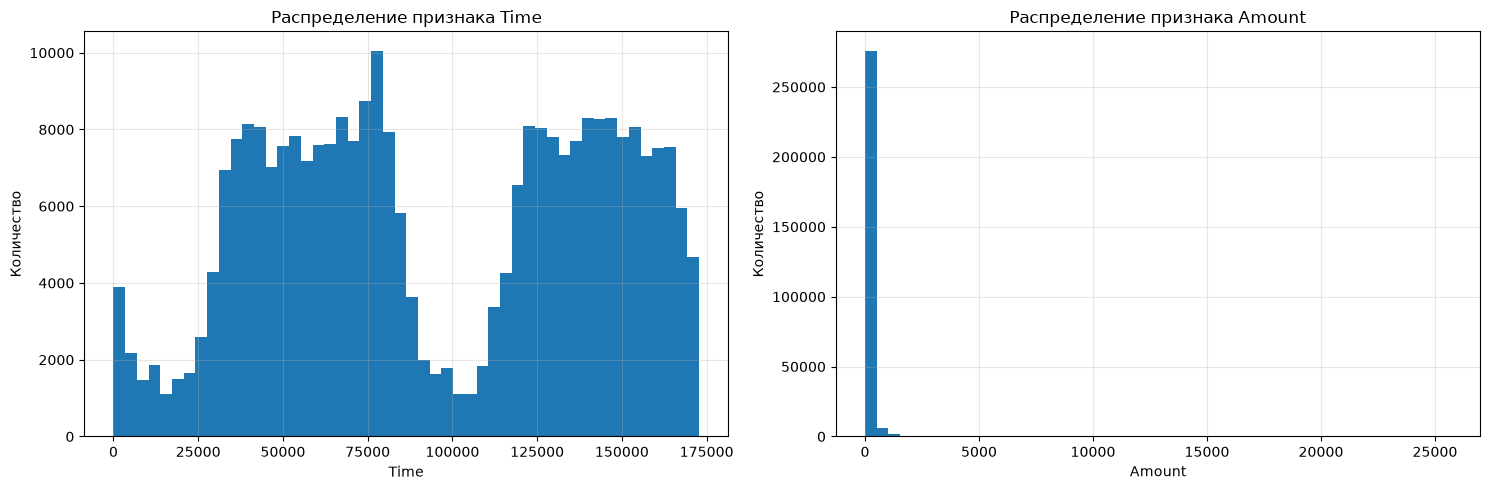

In [60]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

axes[0].hist(
    df["Time"],
    bins=50
)
axes[0].set_title("Распределение признака Time")
axes[0].set_xlabel("Time")
axes[0].set_ylabel("Количество")
axes[0].grid(alpha=0.3)

axes[1].hist(
    df["Amount"],
    bins=50
)
axes[1].set_title("Распределение признака Amount")
axes[1].set_xlabel("Amount")
axes[1].set_ylabel("Количество")
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

### 4.1 Распределения PCA-признаков

Построим гистограммы для признаков `V1–V28`.

Так как признаки были получены после PCA-преобразования, многие из них должны быть сосредоточены около нуля. При этом отдельные признаки могут содержать выраженные хвосты и выбросы, что потенциально полезно для алгоритмов поиска аномалий.

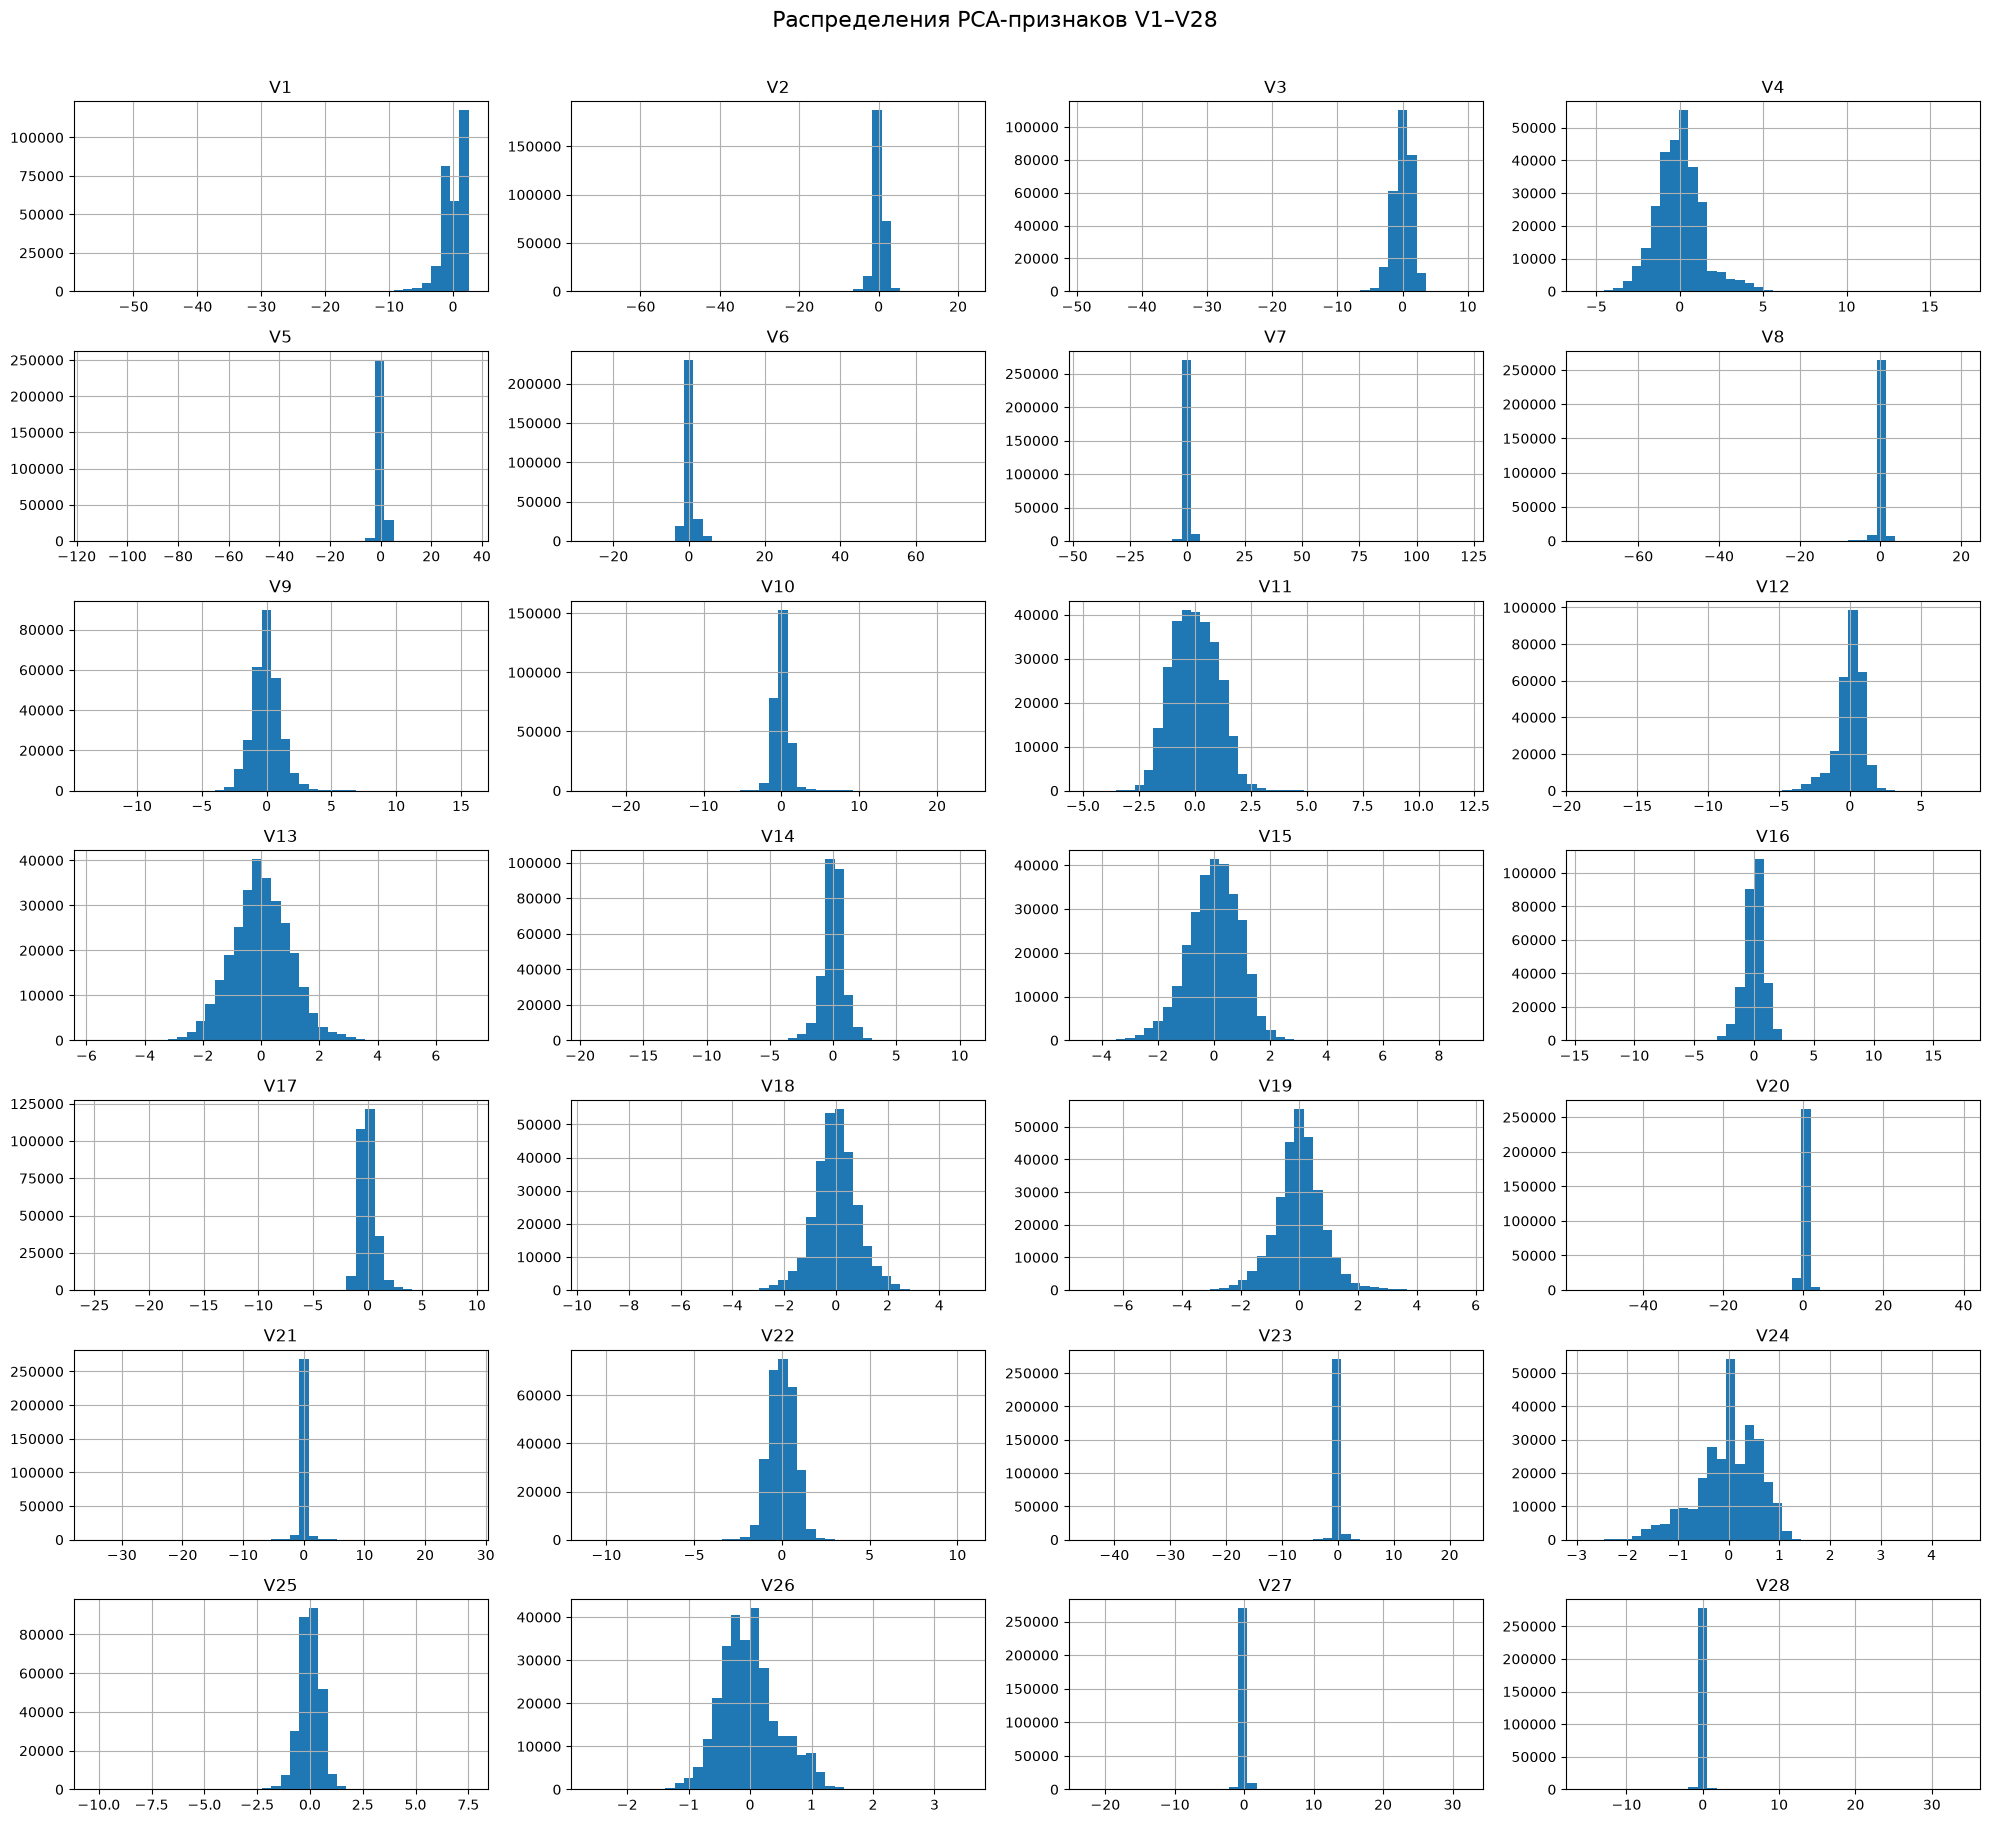

In [61]:
pca_columns = [
    f"V{i}"
    for i in range(1, 29)
]

df[pca_columns].hist(
    bins=40,
    figsize=(20, 18),
    layout=(7, 4)
)

plt.suptitle(
    "Распределения PCA-признаков V1–V28",
    fontsize=16,
    y=1.01
)

plt.tight_layout()
plt.show()

### Вывод по EDA

Проведённый анализ показывает, что датасет имеет выраженный дисбаланс классов: мошеннические транзакции составляют лишь около 0.17% всех наблюдений.

Признаки `V1–V28` имеют различные распределения и масштабы, а признаки `Time` и `Amount` отличаются по диапазонам значений от PCA-компонент.

Перед применением алгоритмов, основанных на расстояниях и локальной плотности, необходимо выполнить масштабирование признаков.

## 5. Подготовка данных для поиска аномалий

Для обучения unsupervised-моделей целевая переменная `Class` не используется как входной признак.

Она применяется только для:

- вычисления экспертной оценки `contamination`;
- сохранения редкого класса при формировании вычислительной подвыборки;
- последующей оценки качества полученных предсказаний.

Так как алгоритмы на основе расстояний и локальной плотности чувствительны к масштабу признаков, выполним стандартизацию данных с помощью `StandardScaler`.

Для вычислительно тяжёлых алгоритмов используем стратифицированную выборку, сохраняя исходное соотношение нормальных и мошеннических транзакций. Сами модели получают только признаки и не используют `Class` при поиске аномалий.


In [62]:
WORK_SAMPLE_SIZE = 40000

if len(df) > WORK_SAMPLE_SIZE:
    work_df, _ = train_test_split(
        df,
        train_size=WORK_SAMPLE_SIZE,
        stratify=df["Class"],
        random_state=RANDOM_STATE
    )
else:
    work_df = df.copy()

work_df = work_df.reset_index(drop=True)

X = work_df.drop(
    columns=["Class"]
)

y = work_df["Class"].astype(int)

print("=" * 70)
print("РАБОЧАЯ ВЫБОРКА")
print("=" * 70)

print(f"Размер выборки: {work_df.shape}")

print(
    f"Нормальных транзакций: "
    f"{(y == 0).sum()}"
)

print(
    f"Мошеннических транзакций: "
    f"{(y == 1).sum()}"
)

print(
    f"Доля аномалий в рабочей выборке: "
    f"{y.mean():.8f}"
)

print(
    f"Доля аномалий в исходном датасете: "
    f"{contamination:.8f}"
)

РАБОЧАЯ ВЫБОРКА
Размер выборки: (40000, 31)
Нормальных транзакций: 39931
Мошеннических транзакций: 69
Доля аномалий в рабочей выборке: 0.00172500
Доля аномалий в исходном датасете: 0.00172749


In [63]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

print("=" * 70)
print("МАСШТАБИРОВАНИЕ")
print("=" * 70)

print(
    f"Размер массива после масштабирования: "
    f"{X_scaled.shape}"
)

print(
    "\nСреднее первых 5 признаков:"
)
print(
    np.round(
        X_scaled.mean(axis=0)[:5],
        4
    )
)

print(
    "\nСтандартное отклонение первых 5 признаков:"
)
print(
    np.round(
        X_scaled.std(axis=0)[:5],
        4
    )
)

МАСШТАБИРОВАНИЕ
Размер массива после масштабирования: (40000, 30)

Среднее первых 5 признаков:
[ 0. -0. -0. -0.  0.]

Стандартное отклонение первых 5 признаков:
[1. 1. 1. 1. 1.]


## 6. Поиск аномалий на основе расстояний

Первым рассмотрим подход, основанный на расстоянии Махаланобиса.

В отличие от обычного евклидова расстояния, расстояние Махаланобиса учитывает ковариационную структуру признаков. Это особенно полезно в многомерном пространстве, где признаки могут быть взаимосвязаны.

Объекты, находящиеся далеко от центра распределения, будут рассматриваться как потенциальные аномалии.

Порог для определения аномалий выберем таким образом, чтобы доля обнаруженных выбросов соответствовала экспертной оценке загрязнённости данных, рассчитанной ранее по переменной `Class`.

In [64]:
print("=" * 70)
print("MAHALANOBIS DISTANCE")
print("=" * 70)

covariance_model = LedoitWolf()

covariance_model.fit(X_scaled)

center = covariance_model.location_
precision_matrix = covariance_model.precision_

difference = X_scaled - center

mahalanobis_scores = np.sqrt(
    np.einsum(
        "ij,jk,ik->i",
        difference,
        precision_matrix,
        difference
    )
)

mahalanobis_threshold = np.quantile(
    mahalanobis_scores,
    1 - contamination
)

mahalanobis_pred = (
    mahalanobis_scores >= mahalanobis_threshold
).astype(int)

print(f"Порог аномальности: {mahalanobis_threshold:.6f}")

print(
    f"Количество предсказанных аномалий: "
    f"{mahalanobis_pred.sum()}"
)

print(
    f"Доля предсказанных аномалий: "
    f"{mahalanobis_pred.mean():.8f}"
)

print(
    f"Процент предсказанных аномалий: "
    f"{mahalanobis_pred.mean() * 100:.6f}%"
)

MAHALANOBIS DISTANCE
Порог аномальности: 28.118361
Количество предсказанных аномалий: 70
Доля предсказанных аномалий: 0.00175000
Процент предсказанных аномалий: 0.175000%


### 6.1 Оценка качества Mahalanobis Distance

Хотя модель обучается без использования целевой переменной `Class`, после получения предсказаний можно сравнить найденные аномалии с известными мошенническими транзакциями.

Для оценки качества используем:

- `classification_report`;
- `confusion_matrix`;
- ROC-AUC;
- PR-AUC.

Для сильно несбалансированной задачи особенно важны `Recall`, `F1-score` и `PR-AUC` для класса `Fraud`.

In [65]:
print("=" * 70)
print("CLASSIFICATION REPORT — MAHALANOBIS DISTANCE")
print("=" * 70)

print(
    classification_report(
        y,
        mahalanobis_pred,
        target_names=[
            "Normal",
            "Fraud"
        ],
        digits=4,
        zero_division=0
    )
)

cm_mahalanobis = confusion_matrix(
    y,
    mahalanobis_pred
)

roc_auc_mahalanobis = roc_auc_score(
    y,
    mahalanobis_scores
)

pr_auc_mahalanobis = average_precision_score(
    y,
    mahalanobis_scores
)

print("=" * 70)
print("ДОПОЛНИТЕЛЬНЫЕ МЕТРИКИ")
print("=" * 70)

print(
    f"ROC-AUC: "
    f"{roc_auc_mahalanobis:.6f}"
)

print(
    f"PR-AUC: "
    f"{pr_auc_mahalanobis:.6f}"
)

print("\nConfusion Matrix:")
print(cm_mahalanobis)

CLASSIFICATION REPORT — MAHALANOBIS DISTANCE
              precision    recall  f1-score   support

      Normal     0.9988    0.9987    0.9988     39931
       Fraud     0.2857    0.2899    0.2878        69

    accuracy                         0.9975     40000
   macro avg     0.6422    0.6443    0.6433     40000
weighted avg     0.9975    0.9975    0.9975     40000

ДОПОЛНИТЕЛЬНЫЕ МЕТРИКИ
ROC-AUC: 0.931630
PR-AUC: 0.191850

Confusion Matrix:
[[39881    50]
 [   49    20]]


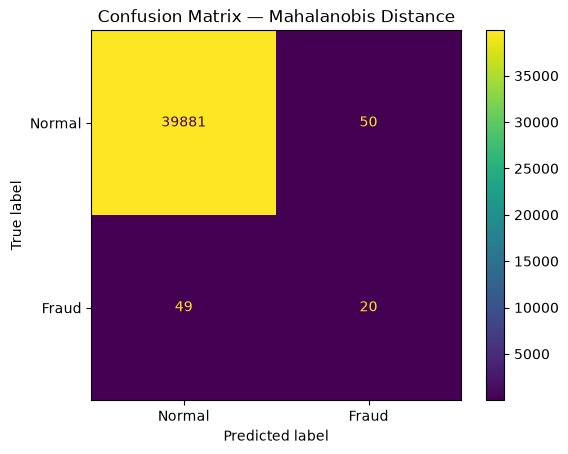

In [66]:
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_mahalanobis,
    display_labels=[
        "Normal",
        "Fraud"
    ]
)

disp.plot(
    values_format="d"
)

plt.title(
    "Confusion Matrix — Mahalanobis Distance"
)

plt.grid(False)
plt.show()

### Вывод по Mahalanobis Distance

Метод расстояния Махаланобиса обнаружил 70 аномальных транзакций, что соответствует примерно 0.175% выборки и близко к экспертной оценке загрязнённости данных.

При этом из 69 реально мошеннических операций удалось обнаружить только 20. Ещё 49 мошеннических транзакций были ошибочно отнесены к нормальным.

Для класса `Fraud` получены следующие результаты:

- Precision ≈ 0.286;
- Recall ≈ 0.290;
- F1-score ≈ 0.288.

Таким образом, метод хорошо классифицирует основную массу нормальных транзакций, но обнаруживает лишь около 29% мошеннических операций.

Высокое значение общей accuracy в данной задаче не является главным показателем качества, поскольку классы сильно несбалансированы. Поэтому для сравнения моделей далее особое внимание будет уделяться метрикам Recall, F1-score и PR-AUC для аномального класса.

## 7. Поиск аномалий на основе локальной плотности

Следующим рассмотрим алгоритм `Local Outlier Factor (LOF)`.

LOF оценивает локальную плотность объектов относительно их ближайших соседей. Если объект находится в области с существенно меньшей плотностью, чем окружающие его точки, он рассматривается как потенциальная аномалия.

В качестве параметра `contamination` используется ранее рассчитанная экспертная оценка доли мошеннических транзакций.

In [67]:
print("=" * 70)
print("LOCAL OUTLIER FACTOR")
print("=" * 70)

lof_model = LocalOutlierFactor(
    n_neighbors=20,
    contamination=contamination,
    n_jobs=-1
)

lof_raw_pred = lof_model.fit_predict(X_scaled)

lof_pred = np.where(
    lof_raw_pred == -1,
    1,
    0
)

lof_scores = -lof_model.negative_outlier_factor_

print(
    f"Количество предсказанных аномалий: "
    f"{lof_pred.sum()}"
)

print(
    f"Доля предсказанных аномалий: "
    f"{lof_pred.mean():.8f}"
)

print(
    f"Процент предсказанных аномалий: "
    f"{lof_pred.mean() * 100:.6f}%"
)

LOCAL OUTLIER FACTOR
Количество предсказанных аномалий: 70
Доля предсказанных аномалий: 0.00175000
Процент предсказанных аномалий: 0.175000%


### 7.1 Оценка качества Local Outlier Factor

Сравним найденные алгоритмом LOF аномалии с истинной переменной `Class`.

Для оценки используем те же метрики, что и для предыдущей модели, чтобы результаты можно было корректно сопоставить.

In [68]:
print("=" * 70)
print("CLASSIFICATION REPORT — LOCAL OUTLIER FACTOR")
print("=" * 70)

print(
    classification_report(
        y,
        lof_pred,
        target_names=[
            "Normal",
            "Fraud"
        ],
        digits=4,
        zero_division=0
    )
)

cm_lof = confusion_matrix(
    y,
    lof_pred
)

roc_auc_lof = roc_auc_score(
    y,
    lof_scores
)

pr_auc_lof = average_precision_score(
    y,
    lof_scores
)

print("=" * 70)
print("ДОПОЛНИТЕЛЬНЫЕ МЕТРИКИ")
print("=" * 70)

print(
    f"ROC-AUC: "
    f"{roc_auc_lof:.6f}"
)

print(
    f"PR-AUC: "
    f"{pr_auc_lof:.6f}"
)

print("\nConfusion Matrix:")
print(cm_lof)

CLASSIFICATION REPORT — LOCAL OUTLIER FACTOR
              precision    recall  f1-score   support

      Normal     0.9983    0.9983    0.9983     39931
       Fraud     0.0286    0.0290    0.0288        69

    accuracy                         0.9966     40000
   macro avg     0.5134    0.5136    0.5135     40000
weighted avg     0.9966    0.9966    0.9966     40000

ДОПОЛНИТЕЛЬНЫЕ МЕТРИКИ
ROC-AUC: 0.649397
PR-AUC: 0.021324

Confusion Matrix:
[[39863    68]
 [   67     2]]


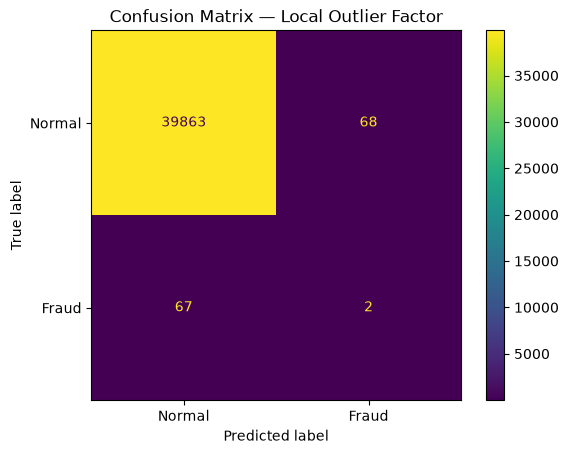

In [69]:
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_lof,
    display_labels=[
        "Normal",
        "Fraud"
    ]
)

disp.plot(
    values_format="d"
)

plt.title(
    "Confusion Matrix — Local Outlier Factor"
)

plt.grid(False)
plt.show()

### Вывод по Local Outlier Factor

Алгоритм Local Outlier Factor обнаружил 70 аномальных объектов, что также соответствует примерно 0.175% рабочей выборки.

Однако качество обнаружения мошеннических транзакций оказалось очень низким.

Из 69 реальных мошеннических операций алгоритм обнаружил только 2, а 67 были ошибочно отнесены к нормальным.

Для класса `Fraud` получены следующие результаты:

- Precision ≈ 0.029;
- Recall ≈ 0.029;
- F1-score ≈ 0.029.

Таким образом, в текущем пространстве признаков локальная плотность объектов плохо отделяет мошеннические транзакции от основной массы данных.

По сравнению с Mahalanobis Distance алгоритм LOF показывает значительно более слабый результат.

## 8. Модельный метод поиска аномалий — Isolation Forest

Следующим рассмотрим алгоритм `Isolation Forest`.

В отличие от методов, основанных непосредственно на расстояниях или локальной плотности, Isolation Forest ищет аномалии путём случайного разбиения пространства признаков.

Идея метода состоит в том, что редкие и необычные объекты обычно изолируются меньшим количеством разбиений, чем наблюдения из основной массы данных.

В качестве параметра `contamination` снова используется экспертная оценка доли мошеннических транзакций.

In [70]:
print("=" * 70)
print("ISOLATION FOREST")
print("=" * 70)

isolation_forest = IsolationForest(
    n_estimators=300,
    contamination=contamination,
    random_state=RANDOM_STATE,
    n_jobs=-1
)

isolation_raw_pred = isolation_forest.fit_predict(
    X_scaled
)

isolation_pred = np.where(
    isolation_raw_pred == -1,
    1,
    0
)

isolation_scores = -isolation_forest.score_samples(
    X_scaled
)

print(
    f"Количество предсказанных аномалий: "
    f"{isolation_pred.sum()}"
)

print(
    f"Доля предсказанных аномалий: "
    f"{isolation_pred.mean():.8f}"
)

print(
    f"Процент предсказанных аномалий: "
    f"{isolation_pred.mean() * 100:.6f}%"
)

ISOLATION FOREST
Количество предсказанных аномалий: 70
Доля предсказанных аномалий: 0.00175000
Процент предсказанных аномалий: 0.175000%


### 8.1 Оценка качества Isolation Forest

Сравним найденные Isolation Forest аномалии с истинными значениями переменной `Class`.

Используем те же метрики, что и для предыдущих алгоритмов:

- classification report;
- confusion matrix;
- ROC-AUC;
- PR-AUC.

In [71]:
print("=" * 70)
print("CLASSIFICATION REPORT — ISOLATION FOREST")
print("=" * 70)

print(
    classification_report(
        y,
        isolation_pred,
        target_names=[
            "Normal",
            "Fraud"
        ],
        digits=4,
        zero_division=0
    )
)

cm_isolation = confusion_matrix(
    y,
    isolation_pred
)

roc_auc_isolation = roc_auc_score(
    y,
    isolation_scores
)

pr_auc_isolation = average_precision_score(
    y,
    isolation_scores
)

print("=" * 70)
print("ДОПОЛНИТЕЛЬНЫЕ МЕТРИКИ")
print("=" * 70)

print(
    f"ROC-AUC: "
    f"{roc_auc_isolation:.6f}"
)

print(
    f"PR-AUC: "
    f"{pr_auc_isolation:.6f}"
)

print("\nConfusion Matrix:")
print(cm_isolation)

CLASSIFICATION REPORT — ISOLATION FOREST
              precision    recall  f1-score   support

      Normal     0.9988    0.9988    0.9988     39931
       Fraud     0.3000    0.3043    0.3022        69

    accuracy                         0.9976     40000
   macro avg     0.6494    0.6516    0.6505     40000
weighted avg     0.9976    0.9976    0.9976     40000

ДОПОЛНИТЕЛЬНЫЕ МЕТРИКИ
ROC-AUC: 0.928395
PR-AUC: 0.183807

Confusion Matrix:
[[39882    49]
 [   48    21]]


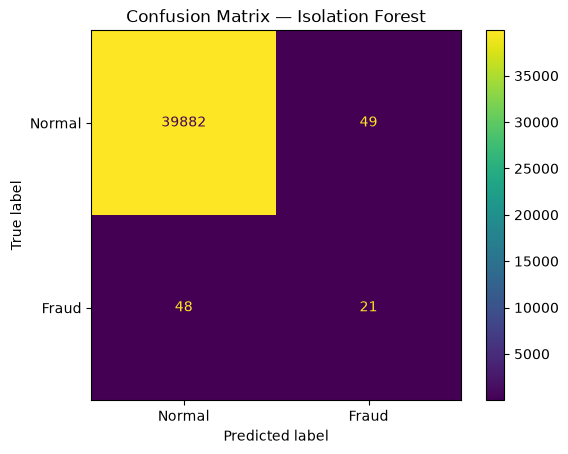

In [72]:
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_isolation,
    display_labels=[
        "Normal",
        "Fraud"
    ]
)

disp.plot(
    values_format="d"
)

plt.title(
    "Confusion Matrix — Isolation Forest"
)

plt.grid(False)
plt.show()

### Вывод по Isolation Forest

Isolation Forest обнаружил 70 аномальных транзакций, что соответствует примерно 0.175% рабочей выборки.

Из 69 реально мошеннических операций модель обнаружила 21, а 48 были пропущены.

Для класса `Fraud` получены следующие результаты:

- Precision = 0.300;
- Recall ≈ 0.304;
- F1-score ≈ 0.302.

Таким образом, Isolation Forest показывает лучший результат среди рассмотренных на текущем этапе методов.

По сравнению с Mahalanobis Distance модель обнаруживает немного больше мошеннических операций и получает более высокий F1-score. Local Outlier Factor при этом значительно уступает обоим методам.

## 9. Сравнение моделей

Сравним все рассмотренные методы по качеству обнаружения мошеннических транзакций.

Поскольку данные сильно несбалансированы, общая Accuracy не является достаточно информативной метрикой. Основное внимание будем уделять качеству обнаружения класса `Fraud`.

Для сравнения используем:

- Precision для класса `Fraud`;
- Recall для класса `Fraud`;
- F1-score для класса `Fraud`;
- ROC-AUC;
- PR-AUC.

Особенно важной является PR-AUC, так как эта метрика хорошо отражает качество модели при сильном дисбалансе классов.

In [73]:
results_df = pd.DataFrame({
    "Model": [
        "Mahalanobis Distance",
        "Local Outlier Factor",
        "Isolation Forest"
    ],
    "Precision Fraud": [
        precision_score(y, mahalanobis_pred, zero_division=0),
        precision_score(y, lof_pred, zero_division=0),
        precision_score(y, isolation_pred, zero_division=0)
    ],
    "Recall Fraud": [
        recall_score(y, mahalanobis_pred, zero_division=0),
        recall_score(y, lof_pred, zero_division=0),
        recall_score(y, isolation_pred, zero_division=0)
    ],
    "F1 Fraud": [
        f1_score(y, mahalanobis_pred, zero_division=0),
        f1_score(y, lof_pred, zero_division=0),
        f1_score(y, isolation_pred, zero_division=0)
    ],
    "ROC-AUC": [
        roc_auc_mahalanobis,
        roc_auc_lof,
        roc_auc_isolation
    ],
    "PR-AUC": [
        pr_auc_mahalanobis,
        pr_auc_lof,
        pr_auc_isolation
    ]
})

results_df = results_df.sort_values(
    by="F1 Fraud",
    ascending=False
).reset_index(drop=True)

print("=" * 90)
print("СРАВНЕНИЕ АЛГОРИТМОВ")
print("=" * 90)

display(
    results_df.style.format({
        "Precision Fraud": "{:.4f}",
        "Recall Fraud": "{:.4f}",
        "F1 Fraud": "{:.4f}",
        "ROC-AUC": "{:.4f}",
        "PR-AUC": "{:.4f}"
    })
)


NameError: name 'precision_score' is not defined

### 9.1 Вывод по сравнению моделей

Результаты показывают, что рассмотренные методы существенно отличаются по способности обнаруживать мошеннические транзакции.

`Isolation Forest` показал наилучший F1-score для класса `Fraud` — около 0.302. Модель обнаруживает примерно 30% мошеннических транзакций и показывает наиболее сбалансированное соотношение Precision и Recall.

`Mahalanobis Distance` немного уступает Isolation Forest по F1-score, однако показывает лучшие значения ROC-AUC и PR-AUC. Это означает, что рассчитанный моделью непрерывный показатель аномальности достаточно хорошо ранжирует мошеннические транзакции, несмотря на неидеальное качество классификации при выбранном пороге.

`Local Outlier Factor` показал значительно более слабый результат: ему удалось обнаружить только небольшую часть мошеннических операций.

Таким образом, наиболее эффективными из рассмотренных методов оказались Isolation Forest и Mahalanobis Distance.

### 9.2 Визуальное сравнение качества моделей

Для наглядности сравним F1-score моделей для класса `Fraud`.

Чем выше F1-score, тем лучше баланс между Precision и Recall при обнаружении мошеннических транзакций.

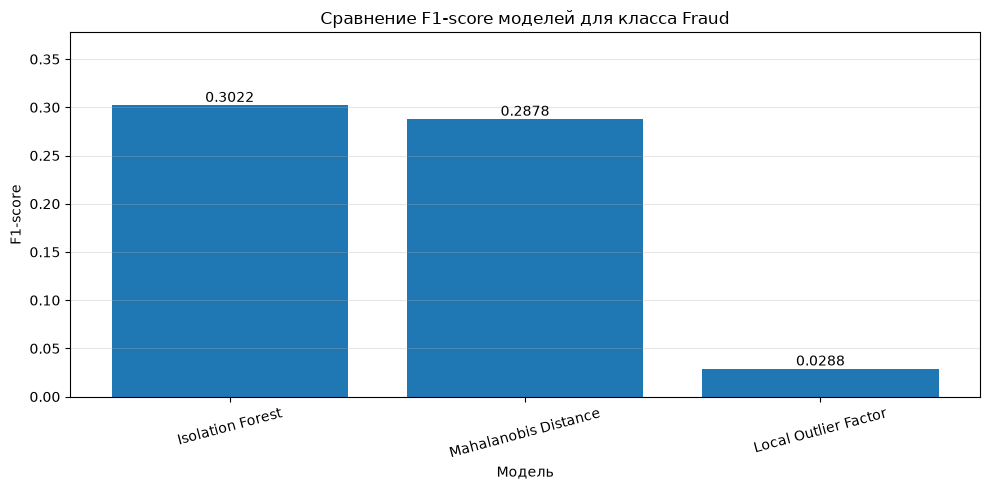

In [50]:
plt.figure(figsize=(10, 5))

plt.bar(
    results_df["Model"],
    results_df["F1 Fraud"]
)

plt.title(
    "Сравнение F1-score моделей для класса Fraud"
)

plt.xlabel("Модель")
plt.ylabel("F1-score")

plt.ylim(
    0,
    max(results_df["F1 Fraud"]) * 1.25
)

plt.grid(
    axis="y",
    alpha=0.3
)

for i, value in enumerate(results_df["F1 Fraud"]):
    plt.text(
        i,
        value,
        f"{value:.4f}",
        ha="center",
        va="bottom"
    )

plt.xticks(
    rotation=15
)

plt.tight_layout()
plt.show()

## 10. Визуализация данных с помощью t-SNE

Для дополнительного анализа проверим, насколько мошеннические транзакции визуально отделяются от основной массы наблюдений.

Исходные данные имеют 30 признаков, поэтому напрямую отобразить их невозможно. Для уменьшения размерности используем алгоритм `t-SNE`, который преобразует многомерные данные в двумерное пространство, стараясь сохранить локальную структуру объектов.

Так как полный датасет содержит почти 285 тысяч транзакций, применение t-SNE ко всем объектам потребовало бы значительных вычислительных ресурсов.

Поэтому для визуализации используем:

- 8000 случайно выбранных нормальных транзакций;
- все 492 мошеннические транзакции.

Такой подход позволяет сохранить все интересующие нас аномальные наблюдения и одновременно существенно сократить время вычислений.

Важно: соотношение классов в этой визуализационной выборке намеренно отличается от исходного датасета, поскольку все мошеннические транзакции сохранены для наглядности. Поэтому t-SNE используется только для анализа взаимного расположения объектов, а не для оценки реальной доли мошенничества.


In [51]:
NORMAL_TSNE_SIZE = 8000

normal_df = df[
    df["Class"] == 0
]

fraud_df = df[
    df["Class"] == 1
]

normal_tsne = normal_df.sample(
    n=min(
        NORMAL_TSNE_SIZE,
        len(normal_df)
    ),
    random_state=RANDOM_STATE
)

tsne_df = pd.concat(
    [
        normal_tsne,
        fraud_df
    ],
    ignore_index=True
)

tsne_df = tsne_df.sample(
    frac=1,
    random_state=RANDOM_STATE
).reset_index(drop=True)

X_tsne = tsne_df.drop(
    columns=["Class"]
)

y_tsne = tsne_df[
    "Class"
].astype(int)

tsne_scaler = StandardScaler()

X_tsne_scaled = tsne_scaler.fit_transform(
    X_tsne
)

print("=" * 70)
print("ВЫБОРКА ДЛЯ t-SNE")
print("=" * 70)

print(
    f"Всего объектов: "
    f"{len(tsne_df)}"
)

print(
    f"Нормальных транзакций: "
    f"{(y_tsne == 0).sum()}"
)

print(
    f"Мошеннических транзакций: "
    f"{(y_tsne == 1).sum()}"
)

print(
    f"Количество признаков: "
    f"{X_tsne_scaled.shape[1]}"
)

ВЫБОРКА ДЛЯ t-SNE
Всего объектов: 8492
Нормальных транзакций: 8000
Мошеннических транзакций: 492
Количество признаков: 30


### 10.1 Построение двумерного представления

Теперь применим t-SNE к подготовленной выборке.

Если мошеннические операции действительно существенно отличаются от нормальных транзакций, часть таких объектов может образовывать отдельные группы либо располагаться вдали от основной массы точек.

In [52]:
print("=" * 70)
print("ПОСТРОЕНИЕ t-SNE")
print("=" * 70)

tsne_model = TSNE(
    n_components=2,
    perplexity=30,
    learning_rate="auto",
    init="pca",
    max_iter=1000,
    random_state=RANDOM_STATE
)

X_tsne_2d = tsne_model.fit_transform(
    X_tsne_scaled
)

print("t-SNE успешно построен.")

print(
    f"Размер двумерного пространства: "
    f"{X_tsne_2d.shape}"
)

ПОСТРОЕНИЕ t-SNE
t-SNE успешно построен.
Размер двумерного пространства: (8492, 2)


### 10.2 Визуализация нормальных и мошеннических транзакций

Отобразим полученное двумерное пространство.

Нормальные и мошеннические транзакции будут показаны отдельно, что позволит визуально оценить степень их разделимости.

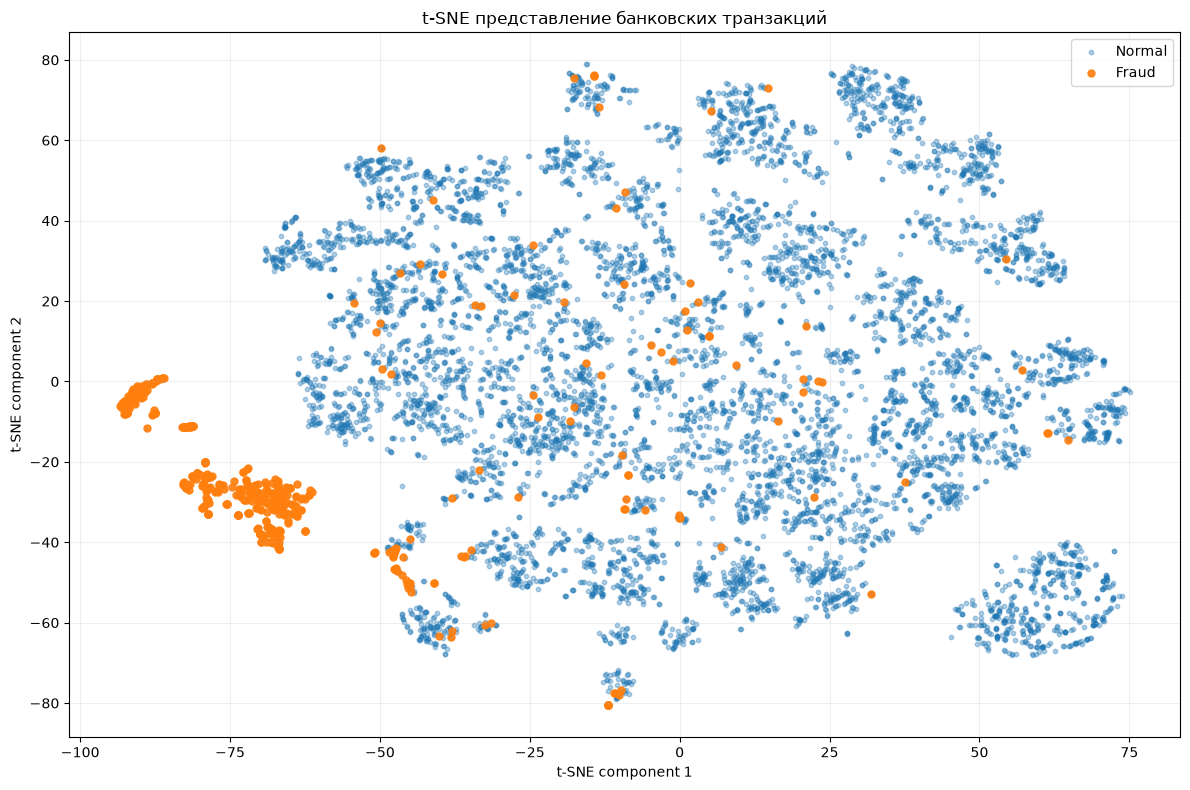

In [53]:
normal_mask = (
    y_tsne.values == 0
)

fraud_mask = (
    y_tsne.values == 1
)

plt.figure(
    figsize=(12, 8)
)

plt.scatter(
    X_tsne_2d[
        normal_mask,
        0
    ],
    X_tsne_2d[
        normal_mask,
        1
    ],
    s=10,
    alpha=0.35,
    label="Normal"
)

plt.scatter(
    X_tsne_2d[
        fraud_mask,
        0
    ],
    X_tsne_2d[
        fraud_mask,
        1
    ],
    s=25,
    alpha=0.9,
    label="Fraud"
)

plt.title(
    "t-SNE представление банковских транзакций"
)

plt.xlabel(
    "t-SNE component 1"
)

plt.ylabel(
    "t-SNE component 2"
)

plt.legend()

plt.grid(
    alpha=0.2
)

plt.tight_layout()
plt.show()

### 10.3 Вывод по t-SNE

В двумерном представлении t-SNE видно, что часть мошеннических транзакций действительно заметно отделяется от основной массы данных.

В частности, несколько групп объектов класса `Fraud` образуют достаточно плотные отдельные кластеры вдали от большинства нормальных транзакций.

При этом часть мошеннических операций располагается внутри областей, содержащих обычные транзакции, и визуально не отделяется от них.

Таким образом, предположение о том, что все аномальные транзакции должны находиться далеко от основной массы точек, подтверждается лишь частично.

Это также объясняет результаты алгоритмов обнаружения аномалий: методы способны успешно обнаруживать наиболее выраженные выбросы, однако часть мошеннических операций по своей структуре похожа на обычные транзакции и поэтому остаётся необнаруженной.

## 11. Итоговый вывод

В рамках работы была построена система обнаружения аномалий в банковских транзакциях.

Исходный датасет содержит 284 807 транзакций и характеризуется крайне сильным дисбалансом классов. Всего 492 операции относятся к мошенническим, что составляет приблизительно 0.173% всех наблюдений.

Полученная доля мошеннических транзакций была использована в качестве экспертной оценки параметра `contamination`.

В работе были рассмотрены три различных подхода к обнаружению аномалий:

1. `Mahalanobis Distance` — метод, основанный на расстоянии;
2. `Local Outlier Factor` — метод, основанный на локальной плотности;
3. `Isolation Forest` — модельный метод обнаружения аномалий.

На рабочей стратифицированной выборке из 40 000 транзакций содержалось 69 мошеннических операций.

### Mahalanobis Distance

Метод обнаружил 20 из 69 мошеннических транзакций.

Для класса `Fraud` были получены приблизительно следующие результаты:

- Precision: 0.286;
- Recall: 0.290;
- F1-score: 0.288;
- ROC-AUC: 0.932;
- PR-AUC: 0.192.

### Local Outlier Factor

LOF показал значительно более слабое качество и обнаружил только 2 из 69 мошеннических операций.

Для класса `Fraud`:

- Precision: 0.029;
- Recall: 0.029;
- F1-score: 0.029;
- ROC-AUC: 0.649;
- PR-AUC: 0.021.

### Isolation Forest

Isolation Forest показал лучший F1-score среди рассмотренных методов и обнаружил 21 из 69 мошеннических транзакций.

Для класса `Fraud`:

- Precision: 0.300;
- Recall: 0.304;
- F1-score: 0.302;
- ROC-AUC: 0.928;
- PR-AUC: 0.184.

Таким образом, по F1-score лучшим алгоритмом оказался `Isolation Forest`, тогда как `Mahalanobis Distance` показал несколько лучшие значения ROC-AUC и PR-AUC.

Высокая Accuracy всех моделей не должна интерпретироваться как показатель высокого качества обнаружения мошенничества, поскольку более 99.8% объектов относятся к нормальному классу.

Визуализация t-SNE показала, что часть мошеннических транзакций действительно формирует отдельные группы и располагается вдали от основной массы нормальных операций. Однако значительная часть аномалий пересекается с нормальными транзакциями.

Следовательно, unsupervised-методы способны находить часть мошеннических операций даже в условиях анонимизированных признаков и крайне сильного дисбаланса классов, однако полностью решить задачу только на основании отклонения объектов от общей структуры данных не удаётся.